## Setup

In [1]:
from time import time
from itertools import product

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from algorithms import plain_smoothed
from targets import Moons

### Hyperparameters

In [4]:
N_samples = 200
training_samples = N_samples
samples_out = N_samples  # Number of samples to be generated
steps_num = 100
sigma_smoothing = 0.1  # Smoothing parameter
M_noise_samples = 100  # M noise samples

## Data

In [5]:
X = Moons().sample(num_samples=training_samples)

## Model

In [6]:
z_list = plain_smoothed(
    X=X, S=steps_num, K=samples_out, sigma=sigma_smoothing, M=M_noise_samples
)

  0%|          | 0/200 [00:00<?, ?it/s]

In [7]:
z_list.shape

(200, 100, 2)

## Visualization

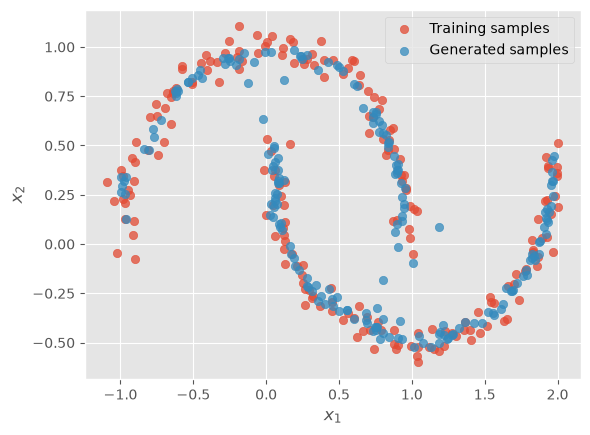

In [8]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.scatter(X[:, 0], X[:, 1], label="Training samples", alpha=0.75)
    ax.scatter(
        z_list[:, -1, 0], z_list[:, -1, 1], label="Generated samples", alpha=0.75
    )
    ax.legend(loc="best")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    plt.show()

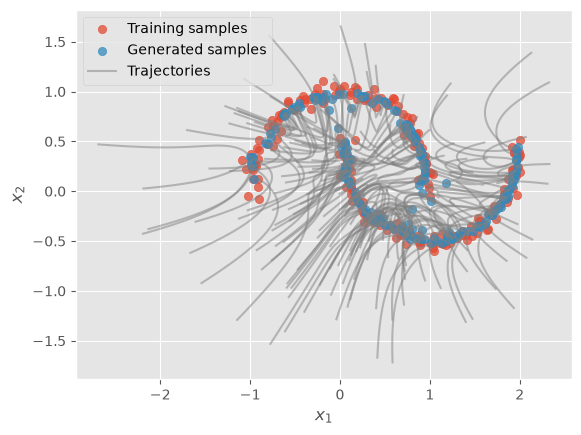

In [9]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.scatter(X[:, 0], X[:, 1], label="Training samples", alpha=0.75)
    ax.scatter(
        z_list[:, -1, 0], z_list[:, -1, 1], label="Generated samples", alpha=0.75
    )
    for traj_i in range(z_list.shape[0]):
        if traj_i == 0:
            ax.plot(
                z_list[traj_i, :, 0],
                z_list[traj_i, :, 1],
                label="Trajectories",
                alpha=0.5,
                color="gray",
            )
        else:
            ax.plot(z_list[traj_i, :, 0], z_list[traj_i, :, 1], alpha=0.5, color="gray")
    ax.legend(loc="best")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    plt.show()